# 04 · Classification: Bank Marketing (Term-Deposit Subscription)
**Group 10: Mobile App Ecosystem Dynamics and Direct Bank Marketing Pipelines**

Dataset: https://archive.ics.uci.edu/dataset/222/bank+marketing (`bank-additional-full.csv`, Portuguese bank, May 2008 – Nov 2010)

**Task:** predict whether a client will subscribe to a term deposit (`y` = yes/no) *before* calling them,
so the call centre can prioritise the clients most likely to say yes.

In [1]:
import sys; sys.path.insert(0, "..")
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             average_precision_score, confusion_matrix, roc_curve, precision_recall_curve)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from src.viz import *

set_style()
SEED = 42
df_raw = pd.read_csv(RAW / "bank_marketing" / "bank-additional" / "bank-additional-full.csv", sep=";")
print(df_raw.shape)
df_raw.head()

(41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 1. Data audit

In [2]:
print("NaN values:", df_raw.isna().sum().sum(), "| Duplicate rows:", df_raw.duplicated().sum())
cat_cols_all = df_raw.select_dtypes("object").columns.drop("y")
unknown = (df_raw[cat_cols_all] == "unknown").sum()
print("'unknown' placeholders:\n", unknown[unknown > 0])
print("\nTarget balance:\n", df_raw["y"].value_counts(normalize=True).round(4))

NaN values: 0 | Duplicate rows: 12
'unknown' placeholders:
 job           330
marital        80
education    1731
default      8597
housing       990
loan          990
dtype: int64

Target balance:
 y
no     0.8873
yes    0.1127
Name: proportion, dtype: float64


/var/folders/v2/qd8hwr253s5_bxd9y6sjfpym0000gn/T/ipykernel_66892/2818788975.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_all = df_raw.select_dtypes("object").columns.drop("y")


## 2. EDA for modelling

findfont: Failed to find font weight semibold for Helvetica Neue, now using 700.


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


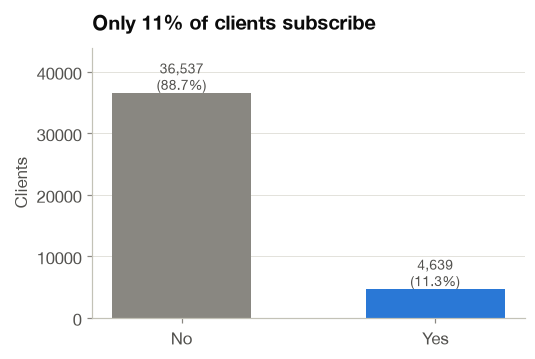

In [3]:
df = df_raw.drop_duplicates().reset_index(drop=True)
df["target"] = (df["y"] == "yes").astype(int)
base_rate = df["target"].mean()

fig, ax = plt.subplots(figsize=(5, 3.4))
vc = df["y"].value_counts()
ax.bar(["No", "Yes"], vc.values, color=[MUTED, BLUE], width=0.55)
for i, v in enumerate(vc.values):
    ax.text(i, v + 500, f"{v:,}\n({v / vc.sum():.1%})", ha="center", color=INK_2, fontsize=9)
ax.set(title="Only 11% of clients subscribe", ylabel="Clients", ylim=(0, vc.max() * 1.2))
ax.grid(axis="x", visible=False)
save(fig, "bk_target_balance")

findfont: Failed to find font weight semibold for Helvetica Neue, now using 700.


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


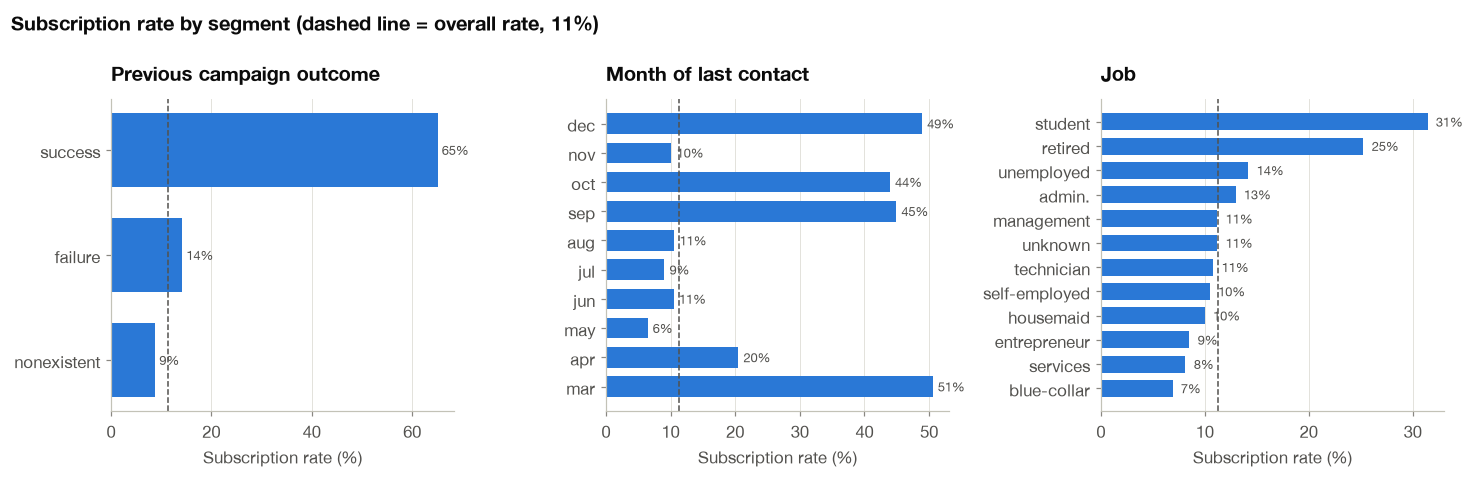

In [4]:
def rate_plot(ax, col, order=None, title=None):
    r = df.groupby(col)["target"].agg(["mean", "size"])
    r = r.loc[order] if order else r.sort_values("mean")
    ax.barh(r.index.astype(str), r["mean"] * 100, color=BLUE, height=0.7)
    ax.axvline(base_rate * 100, color=INK_2, lw=1, ls="--")
    for yv, (m, n) in enumerate(zip(r["mean"], r["size"])):
        ax.text(m * 100 + 0.8, yv, f"{m:.0%}", va="center", fontsize=8.5, color=INK_2)
    ax.set(title=title or col, xlabel="Subscription rate (%)")
    ax.grid(axis="y", visible=False)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.4))
rate_plot(axes[0], "poutcome", title="Previous campaign outcome")
rate_plot(axes[1], "month", order=["mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"],
          title="Month of last contact")
rate_plot(axes[2], "job", title="Job")
fig.suptitle("Subscription rate by segment (dashed line = overall rate, 11%)", x=0.01, ha="left",
             fontweight="semibold")
save(fig, "bk_rate_by_category")

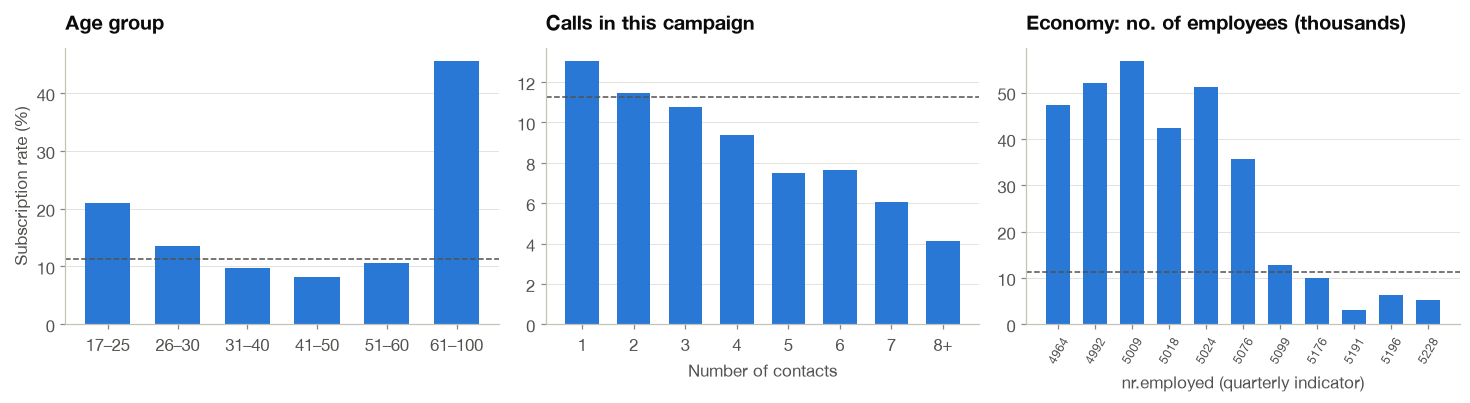

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8))
bins = [16, 25, 30, 40, 50, 60, 100]
a = df.groupby(pd.cut(df["age"], bins), observed=True)["target"].mean() * 100
axes[0].bar([f"{int(i.left) + 1}–{int(i.right)}" for i in a.index], a.values, color=BLUE, width=0.65)
axes[0].set(title="Age group", ylabel="Subscription rate (%)")
c = df.assign(calls=df["campaign"].clip(upper=8)).groupby("calls")["target"].mean() * 100
axes[1].bar([str(i) if i < 8 else "8+" for i in c.index], c.values, color=BLUE, width=0.65)
axes[1].set(title="Calls in this campaign", xlabel="Number of contacts")
e = df.groupby("nr.employed")["target"].mean() * 100
axes[2].bar([f"{v:.0f}" for v in e.index], e.values, color=BLUE, width=0.65)
axes[2].set(title="Economy: no. of employees (thousands)", xlabel="nr.employed (quarterly indicator)")
axes[2].tick_params(axis="x", rotation=60, labelsize=8)
for ax in axes:
    ax.axhline(base_rate * 100, color=INK_2, lw=1, ls="--")
    ax.grid(axis="x", visible=False)
save(fig, "bk_rate_by_numeric")

nr.employed      -0.354669
pdays            -0.324948
euribor3m        -0.307740
emp.var.rate     -0.298289
cons.price.idx   -0.136134
campaign         -0.066361
age               0.030381
cons.conf.idx     0.054802
previous          0.230202
duration          0.405297
Name: target, dtype: float64

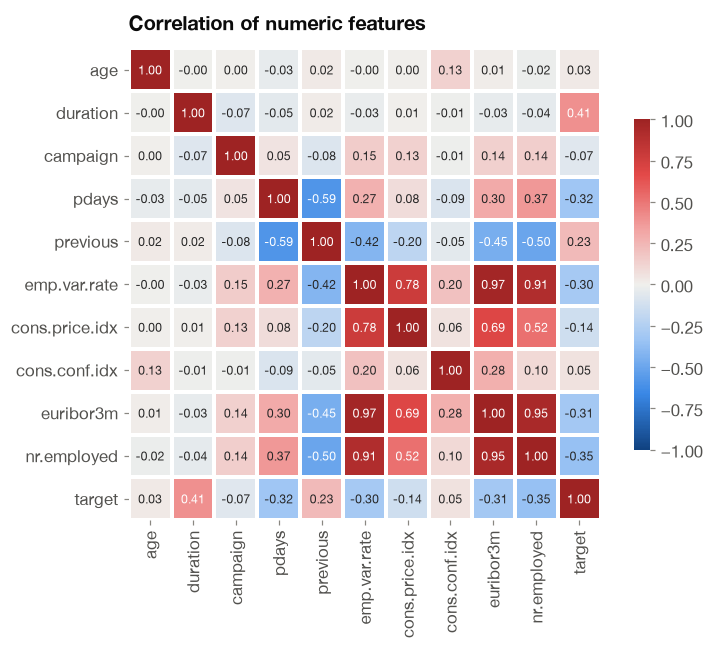

In [6]:
num_all = ["age", "duration", "campaign", "pdays", "previous", "emp.var.rate", "cons.price.idx",
           "cons.conf.idx", "euribor3m", "nr.employed", "target"]
corr = df[num_all].corr()
fig, ax = plt.subplots(figsize=(7.4, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap=DIVERGING, vmin=-1, vmax=1, square=True, linewidths=1.5,
            linecolor=SURFACE, cbar_kws={"shrink": 0.7}, ax=ax, annot_kws={"fontsize": 8})
ax.set(title="Correlation of numeric features")
ax.grid(False)
save(fig, "bk_correlation")
corr["target"].drop("target").sort_values()

**Observations**
- **Leakage:** `duration` (call length) has the highest correlation with the target (0.41) but is only known *after* the call ends — the call decides the outcome. We **drop it** to build a realistic pre-call model.
- **Past success is the strongest signal:** clients whose previous campaign succeeded subscribe ~65 % of the time vs ~11 % overall.
- **Macro-economy matters:** subscription rate is much higher when employment (`nr.employed`) and Euribor rates are low; the 5 macro indicators are highly inter-correlated (up to 0.97).
- **Timing:** March, September, October and December have 44–51 % rates but few calls; May has the most calls and the lowest rate.
- **Diminishing returns:** each additional call in the same campaign lowers the chance of success.
- Students and retirees (youngest/oldest age groups) are the most receptive.

## 3. Feature engineering and preprocessing
- Drop `duration` (leakage) and `y`.
- `pdays` = 999 means "never contacted" (96 %) → binary `prev_contacted`; drop raw `pdays`.
- Keep `unknown` as its own category (it is informative; e.g. `default = unknown` clients subscribe less).
- One-hot encode categoricals, standardise numerics (fitted inside the pipeline on training folds only).
- Stratified 80/20 split keeps the 11 % positive rate in both sets.

In [7]:
df["prev_contacted"] = (df["pdays"] != 999).astype(int)
X = df.drop(columns=["y", "target", "duration", "pdays"])
y = df["target"]
cat_cols = X.select_dtypes("object").columns.tolist()
num_cols = X.select_dtypes("number").columns.tolist()
print("Categorical:", cat_cols, "\nNumeric:", num_cols)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
print(X_train.shape, X_test.shape, f"positive rate train {y_train.mean():.3f} / test {y_test.mean():.3f}")
pd.concat([X, y], axis=1).to_csv(PROCESSED / "bank_marketing_model_ready.csv", index=False)

pre = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
])
spw = (y_train == 0).sum() / (y_train == 1).sum()

/var/folders/v2/qd8hwr253s5_bxd9y6sjfpym0000gn/T/ipykernel_66892/1708390907.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes("object").columns.tolist()


Categorical: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome'] 
Numeric: ['age', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'prev_contacted']
(32940, 19) (8236, 19) positive rate train 0.113 / test 0.113


## 4. Models
Imbalance is handled three ways and compared: **class weights** (`class_weight="balanced"` / `scale_pos_weight`),
**SMOTE** oversampling (inside the CV pipeline, training folds only), and **no handling** (to show the accuracy trap).

In [8]:
def pipe(model, smote=False):
    steps = [("pre", pre)] + ([("smote", SMOTE(random_state=SEED))] if smote else []) + [("model", model)]
    return ImbPipeline(steps)

models = {
    "Baseline (always 'no')": pipe(DummyClassifier(strategy="most_frequent")),
    "Logistic Regression": pipe(LogisticRegression(max_iter=2000)),
    "Logistic Reg. (balanced)": pipe(LogisticRegression(max_iter=2000, class_weight="balanced")),
    "Logistic Reg. + SMOTE": pipe(LogisticRegression(max_iter=2000), smote=True),
    "Naive Bayes": pipe(GaussianNB()),
    "KNN (k=15)": pipe(KNeighborsClassifier(n_neighbors=15)),
    "Decision Tree (balanced)": pipe(DecisionTreeClassifier(max_depth=6, min_samples_leaf=50,
                                                            class_weight="balanced", random_state=SEED)),
    "Random Forest (balanced)": pipe(RandomForestClassifier(n_estimators=400, min_samples_leaf=5,
                                                            class_weight="balanced_subsample",
                                                            n_jobs=-1, random_state=SEED)),
    "Gradient Boosting": pipe(GradientBoostingClassifier(n_estimators=300, max_depth=3, learning_rate=0.05,
                                                         random_state=SEED)),
    "XGBoost (weighted)": pipe(XGBClassifier(n_estimators=500, learning_rate=0.03, max_depth=4, subsample=0.8,
                                             colsample_bytree=0.8, scale_pos_weight=spw, eval_metric="logloss",
                                             random_state=SEED, n_jobs=-1)),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
rows, fitted, probas = [], {}, {}
for name, model in models.items():
    cvres = cross_validate(model, X_train, y_train, cv=cv, n_jobs=-1, scoring=["roc_auc", "f1"])
    t0 = time.time()
    model.fit(X_train, y_train)
    fit_s = time.time() - t0
    p = model.predict_proba(X_test)[:, 1]
    pred = model.predict(X_test)
    fitted[name], probas[name] = model, p
    rows.append({
        "Model": name,
        "CV ROC-AUC": cvres["test_roc_auc"].mean(), "CV ROC-AUC std": cvres["test_roc_auc"].std(),
        "CV F1": cvres["test_f1"].mean(),
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, p),
        "PR-AUC": average_precision_score(y_test, p),
        "Fit time (s)": fit_s,
    })
results = pd.DataFrame(rows)
results.round(4)

,Model,CV ROC-AUC,CV ROC-AUC std,CV F1,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Fit time (s)
0,Baseline (always 'no'),0.5000,0.0000,0.0000,0.8873,0.0000,0.0000,0.0000,0.5000,0.1127,0.1392
1,Logistic Regression,0.7898,0.0072,0.3403,0.8985,0.6523,0.2123,0.3203,0.8006,0.4534,0.2784
2,Logistic Reg. (balanced),0.7905,0.0075,0.4502,0.8305,0.3595,0.6455,0.4618,0.8002,0.4465,0.2439
3,Logistic Reg. + SMOTE,0.7873,0.0082,0.4418,0.8224,0.3471,0.6541,0.4535,0.7991,0.4454,0.5823
4,Naive Bayes,0.7664,0.0107,0.4079,0.8082,0.3199,0.6239,0.4229,0.7761,0.3595,0.0743
5,KNN (k=15),0.7587,0.0061,0.3593,0.8981,0.6115,0.2629,0.3677,0.7728,0.4186,0.0909
6,Decision Tree (balanced),0.7805,0.0115,0.4447,0.8469,0.3901,0.6369,0.4838,0.8015,0.4604,0.1515
7,Random Forest (balanced),0.7944,0.0084,0.4965,0.8732,0.4540,0.6175,0.5233,0.8067,0.4836,2.7284
8,Gradient Boosting,0.7967,0.0077,0.3692,0.8991,0.6448,0.2328,0.3420,0.8108,0.4802,14.8667
9,XGBoost (weighted),0.8008,0.0071,0.4673,0.8448,0.3881,0.6541,0.4872,0.8117,0.4838,0.9601


**The accuracy trap:** the baseline that always predicts "no" gets ~89 % accuracy but finds **zero** subscribers.
Unweighted Logistic Regression looks accurate too, but misses most of the positives. Accuracy is the wrong metric here;
we rank models by **ROC-AUC / PR-AUC** (ranking quality) and **F1 / recall** (finding subscribers).

## 5. Decision-threshold tuning
The default 0.5 threshold is arbitrary for imbalanced data. For the best-ranking model we pick the threshold that
maximises F1 on **out-of-fold predictions of the training set** (the test set is not used to choose it).

In [9]:
ranked = results[results["Model"] != "Baseline (always 'no')"].sort_values("CV ROC-AUC", ascending=False)
best_name = ranked.iloc[0]["Model"]
print("Best by CV ROC-AUC:", best_name)
oof = cross_val_predict(models[best_name], X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
prec, rec, thr = precision_recall_curve(y_train, oof)
f1s = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)
best_thr = float(thr[np.argmax(f1s)])
print(f"F1-optimal threshold (OOF): {best_thr:.3f}")

p = probas[best_name]
pred_t = (p >= best_thr).astype(int)
tuned_row = {"Model": f"{best_name} @ thr {best_thr:.2f}",
             "CV ROC-AUC": ranked.iloc[0]["CV ROC-AUC"], "CV ROC-AUC std": ranked.iloc[0]["CV ROC-AUC std"],
             "CV F1": f1s.max(),
             "Accuracy": accuracy_score(y_test, pred_t), "Precision": precision_score(y_test, pred_t),
             "Recall": recall_score(y_test, pred_t), "F1": f1_score(y_test, pred_t),
             "ROC-AUC": roc_auc_score(y_test, p), "PR-AUC": average_precision_score(y_test, p),
             "Fit time (s)": np.nan}
results = pd.concat([results, pd.DataFrame([tuned_row])]).sort_values("F1", ascending=False).reset_index(drop=True)
results.to_csv(MODELS / "classification_results.csv", index=False)
results.round(4)

Best by CV ROC-AUC: XGBoost (weighted)


F1-optimal threshold (OOF): 0.651


,Model,CV ROC-AUC,CV ROC-AUC std,CV F1,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Fit time (s)
0,XGBoost (weighted) @ thr 0.65,0.8008,0.0071,0.4990,0.8814,0.4788,0.5948,0.5305,0.8117,0.4838,NaN
1,Random Forest (balanced),0.7944,0.0084,0.4965,0.8732,0.4540,0.6175,0.5233,0.8067,0.4836,2.7284
2,XGBoost (weighted),0.8008,0.0071,0.4673,0.8448,0.3881,0.6541,0.4872,0.8117,0.4838,0.9601
3,Decision Tree (balanced),0.7805,0.0115,0.4447,0.8469,0.3901,0.6369,0.4838,0.8015,0.4604,0.1515
4,Logistic Reg. (balanced),0.7905,0.0075,0.4502,0.8305,0.3595,0.6455,0.4618,0.8002,0.4465,0.2439
5,Logistic Reg. + SMOTE,0.7873,0.0082,0.4418,0.8224,0.3471,0.6541,0.4535,0.7991,0.4454,0.5823
6,Naive Bayes,0.7664,0.0107,0.4079,0.8082,0.3199,0.6239,0.4229,0.7761,0.3595,0.0743
7,KNN (k=15),0.7587,0.0061,0.3593,0.8981,0.6115,0.2629,0.3677,0.7728,0.4186,0.0909
8,Gradient Boosting,0.7967,0.0077,0.3692,0.8991,0.6448,0.2328,0.3420,0.8108,0.4802,14.8667
9,Logistic Regression,0.7898,0.0072,0.3403,0.8985,0.6523,0.2123,0.3203,0.8006,0.4534,0.2784


## 6. Comparison charts

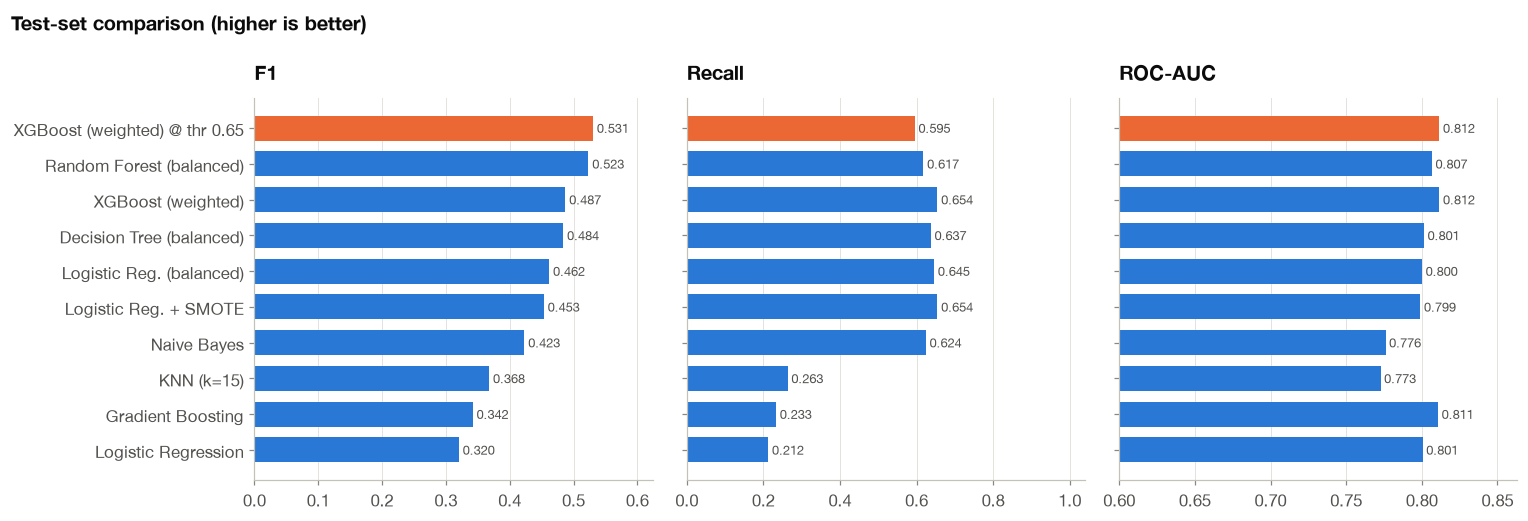

In [10]:
plot = results[~results["Model"].str.startswith("Baseline")].sort_values("F1")
tuned_name = tuned_row["Model"]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.8), sharey=True)
for ax, m, lim in [(axes[0], "F1", (0, 0.6)), (axes[1], "Recall", (0, 1.0)), (axes[2], "ROC-AUC", (0.6, 0.83))]:
    colors = [SERIES[1] if n == tuned_name else BLUE for n in plot["Model"]]
    ax.barh(plot["Model"], plot[m], color=colors, height=0.7)
    for yv, v in enumerate(plot[m]):
        ax.text(v + (lim[1] - lim[0]) * 0.01, yv, f"{v:.3f}", va="center", fontsize=8.5, color=INK_2)
    ax.set(title=m, xlim=(lim[0], lim[1] * 1.04))
    ax.grid(axis="y", visible=False)
fig.suptitle("Test-set comparison (higher is better)", x=0.01, ha="left", fontweight="semibold")
save(fig, "bk_model_comparison")

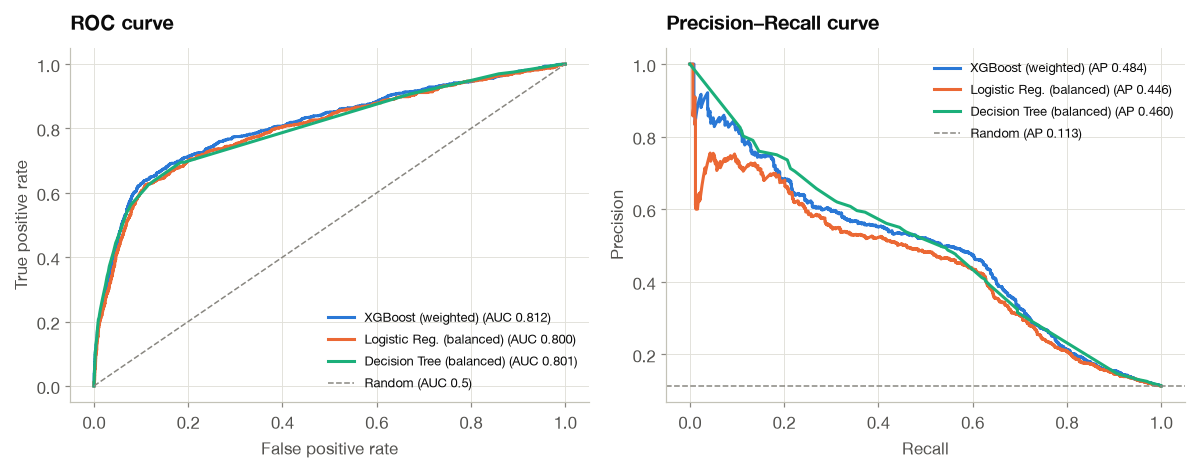

In [11]:
show = [best_name, "Logistic Reg. (balanced)", "Decision Tree (balanced)"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for i, n in enumerate(show):
    fpr, tpr, _ = roc_curve(y_test, probas[n])
    axes[0].plot(fpr, tpr, color=SERIES[i], label=f"{n} (AUC {roc_auc_score(y_test, probas[n]):.3f})")
    pr, rc, _ = precision_recall_curve(y_test, probas[n])
    axes[1].plot(rc, pr, color=SERIES[i], label=f"{n} (AP {average_precision_score(y_test, probas[n]):.3f})")
axes[0].plot([0, 1], [0, 1], color=MUTED, lw=1, ls="--", label="Random (AUC 0.5)")
axes[0].set(title="ROC curve", xlabel="False positive rate", ylabel="True positive rate")
axes[1].axhline(y_test.mean(), color=MUTED, lw=1, ls="--", label=f"Random (AP {y_test.mean():.3f})")
axes[1].set(title="Precision–Recall curve", xlabel="Recall", ylabel="Precision")
for ax in axes:
    ax.legend(loc="lower right" if ax is axes[0] else "upper right", fontsize=8.5)
save(fig, "bk_roc_pr")

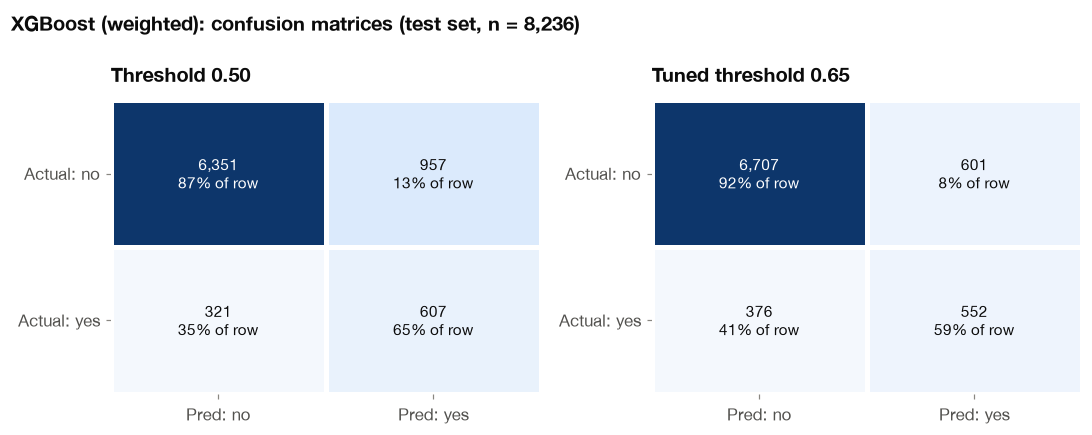

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (title, pr) in zip(axes, [("Threshold 0.50", fitted[best_name].predict(X_test)),
                                   (f"Tuned threshold {best_thr:.2f}", pred_t)]):
    cm = confusion_matrix(y_test, pr)
    sns.heatmap(cm, annot=False, cmap=SEQ_BLUE, cbar=False, linewidths=2, linecolor=SURFACE, ax=ax)
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j + 0.5, i + 0.5, f"{v:,}\n{v / cm[i].sum():.0%} of row", ha="center", va="center",
                color="white" if v > cm.max() * 0.5 else INK, fontsize=10)
    ax.set_xticks([0.5, 1.5], ["Pred: no", "Pred: yes"])
    ax.set_yticks([0.5, 1.5], ["Actual: no", "Actual: yes"], rotation=0)
    ax.set(title=title)
fig.suptitle(f"{best_name}: confusion matrices (test set, n = {len(y_test):,})", x=0.01, ha="left",
             fontweight="semibold")
save(fig, "bk_confusion")

## 7. What drives subscription?

nr.employed       0.0238
emp.var.rate      0.0181
contact           0.0170
euribor3m         0.0141
campaign          0.0070
month             0.0059
cons.conf.idx     0.0048
prev_contacted    0.0030
cons.price.idx    0.0027
poutcome          0.0025
day_of_week       0.0023
default           0.0021
dtype: float64

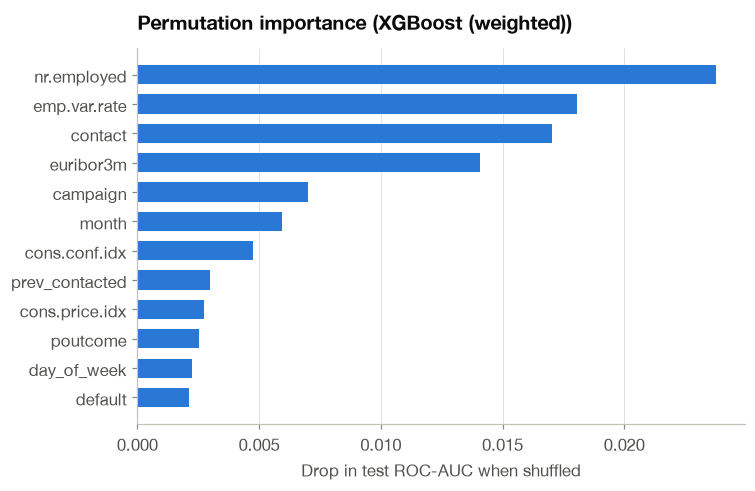

In [13]:
perm = permutation_importance(fitted[best_name], X_test, y_test, n_repeats=10, random_state=SEED,
                              scoring="roc_auc", n_jobs=-1)
imp = pd.Series(perm.importances_mean, index=X_test.columns).sort_values().tail(12)
fig, ax = plt.subplots(figsize=(7, 4.6))
ax.barh(imp.index, imp.values, color=BLUE, height=0.65)
ax.set(title=f"Permutation importance ({best_name})", xlabel="Drop in test ROC-AUC when shuffled")
ax.grid(axis="y", visible=False)
save(fig, "bk_feature_importance")
imp.sort_values(ascending=False).round(4)

Top 20% captures 66.7% of subscribers; lift = 3.34x


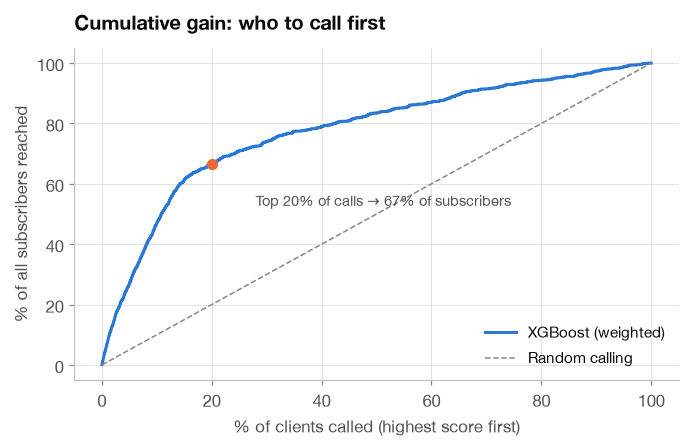

In [14]:
# Business view: calling only the top-scored 20% of clients — what share of all subscribers do we reach?
order = np.argsort(-p)
cum = np.cumsum(y_test.values[order]) / y_test.sum()
k = int(0.2 * len(p))
lift20 = y_test.values[order][:k].mean() / y_test.mean()
fig, ax = plt.subplots(figsize=(6.4, 4.2))
xs = np.arange(1, len(p) + 1) / len(p)
ax.plot(xs * 100, cum * 100, color=BLUE, label=best_name)
ax.plot([0, 100], [0, 100], color=MUTED, lw=1, ls="--", label="Random calling")
ax.scatter([20], [cum[k - 1] * 100], s=40, color=SERIES[1], zorder=3)
ax.annotate(f"Top 20% of calls → {cum[k - 1]:.0%} of subscribers", (20, cum[k - 1] * 100),
            xytext=(28, cum[k - 1] * 100 - 14), color=INK_2, fontsize=9.5)
ax.set(title="Cumulative gain: who to call first", xlabel="% of clients called (highest score first)",
       ylabel="% of all subscribers reached")
ax.legend(loc="lower right")
save(fig, "bk_gain_curve")
print(f"Top 20% captures {cum[k - 1]:.1%} of subscribers; lift = {lift20:.2f}x")

In [15]:
b = results.set_index("Model")
summary = {
    "rows": len(df), "features_used": X.shape[1], "train": len(X_train), "test": len(X_test),
    "positive_rate": base_rate * 100, "best_model": best_name, "threshold": best_thr,
    "best_default": b.loc[best_name].to_dict(), "best_tuned": b.loc[tuned_name].to_dict(),
    "baseline": b.loc["Baseline (always 'no')"].to_dict(),
    "logreg_plain": b.loc["Logistic Regression"].to_dict(),
    "top20_capture_pct": cum[k - 1] * 100, "lift_top20": lift20,
    "importance_top": imp.sort_values(ascending=False).head(6).to_dict(),
    "corr_duration_target": corr.loc["duration", "target"],
    "poutcome_success_rate": df.loc[df["poutcome"] == "success", "target"].mean() * 100,
    "month_rates": (df.groupby("month")["target"].mean() * 100).round(1).to_dict(),
    "month_counts": df["month"].value_counts().to_dict(),
    "job_rates": (df.groupby("job")["target"].mean() * 100).round(1).to_dict(),
    "cm_tuned": confusion_matrix(y_test, pred_t).tolist(),
    "cm_default": confusion_matrix(y_test, fitted[best_name].predict(X_test)).tolist(),
}
save_json(summary, "classification_summary")
pd.Series(summary)

rows                                                                 41176
features_used                                                           19
train                                                                32940
test                                                                  8236
positive_rate                                                    11.266272
best_model                                              XGBoost (weighted)
threshold                                                         0.651094
best_default             {'CV ROC-AUC': 0.8008304351546803, 'CV ROC-AUC...
best_tuned               {'CV ROC-AUC': 0.8008304351546803, 'CV ROC-AUC...
baseline                 {'CV ROC-AUC': 0.5, 'CV ROC-AUC std': 0.0, 'CV...
logreg_plain             {'CV ROC-AUC': 0.7897614339077195, 'CV ROC-AUC...
top20_capture_pct                                                66.702586
lift_top20                                                        3.335534
importance_top           

**Interpretation**
1. **Best model: XGBoost with class weighting**, highest CV ROC-AUC (0.801 ± 0.007) and test ROC-AUC 0.812. With the F1-optimal threshold (0.65, chosen on training OOF predictions) it reaches **F1 = 0.53, precision 0.48, recall 0.60**; Random Forest (balanced) is a close second (F1 0.52).
2. **Imbalance handling is essential**: plain Logistic Regression and Gradient Boosting have ~90 % accuracy but recall of only ~0.21–0.23. Class weights or SMOTE triple the recall at similar ROC-AUC. Class weights ≈ SMOTE here, and weights are simpler/faster.
3. **Ranking ability is similar across good models** (ROC-AUC 0.80–0.81): the signal available *before* a call is limited, which is why the leaky `duration` feature would inflate results (models that include it commonly report AUC > 0.9).
4. **Threshold is a business lever**: moving from 0.50 → 0.65 cuts wasted calls (false positives 957 → 601) at the cost of missing some subscribers (true positives 607 → 552).
5. **Business value**: calling the top 20 % of clients ranked by the model reaches **67 % of all subscribers**, i.e. **3.3× lift** over random calling.
6. **Drivers**: macro-economic context (`nr.employed`, `emp.var.rate`, `euribor3m`) dominates, then contact channel (cellular > telephone), number of calls in the campaign and month. Campaigns should be timed with economic conditions, use mobile contact, and avoid repeatedly calling the same client.